In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.neural_network import MLPClassifier

In [2]:
# Set plotting style
plt.rcParams.update({
    "grid.linewidth":   0.5,
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"
PALETTE = [BLUE, TEAL, AMBER, CORAL, PURPLE, GRAY,
           "#639922","#BA7517","#185FA5","#3B6D11"]

In [3]:
#file_path = r""
df = pd.read_csv("dataset_mood_smartphone.csv")

In [4]:
# Add date and hour only columns 
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.day_name()
df["month"] = df["time"].dt.month_name()
df["weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])
df.head()

,Unnamed: 0,id,time,variable,value,date,hour,day_of_week,month,weekend
0,1,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26,13,Wednesday,February,False
1,2,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26,15,Wednesday,February,False
2,3,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26,18,Wednesday,February,False
3,4,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26,21,Wednesday,February,False
4,5,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27,9,Thursday,February,False


## Exploratory Data Analysis

### 1A & 1B

In [5]:
print("Number of observations x Number of columns:", df.shape)
print("Earliest timestamp:", df['time'].min())
print("Latest timestamp", df['time'].max())
print("Unique users:", df['id'].nunique())
print("Unique variables:", df['variable'].nunique())
print("Total missing values (in value column):", df['value'].isnull().sum())

Number of observations x Number of columns: (376912, 10)
Earliest timestamp: 2014-02-17 07:00:52.197000
Latest timestamp 2014-06-09 00:00:00
Unique users: 27
Unique variables: 19
Total missing values (in value column): 202


In [6]:
grouped = df.groupby("variable")["value"]
# Total count and missing count per variable
total_per_variable = grouped.count()
missing_per_variable = grouped.size() - grouped.count()
missing_pct = (missing_per_variable / (missing_per_variable + total_per_variable)) * 100

stats = grouped.describe().rename(columns={"50%": "median"})
stats["missing"] = missing_per_variable
stats["missing %"] = missing_pct.round(1).fillna(100.0)
stats
## remove negative values
## for Nas in arousal and valence, wait until we impute

,count,mean,std,min,25%,median,75%,max,missing,missing %
variable,,,,,,,,,,
activity,22965.0,0.115958,0.186946,0.000,0.00000,0.021739,0.158333,1.000,0,0.0
appCat.builtin,91288.0,18.538262,415.989243,-82798.871,2.02000,4.038000,9.922000,33960.246,0,0.0
appCat.communication,74276.0,43.343792,128.912750,0.006,5.21800,16.225500,45.475750,9830.777,0,0.0
appCat.entertainment,27125.0,37.576480,262.960476,-0.011,1.33400,3.391000,14.922000,32148.677,0,0.0
appCat.finance,939.0,21.755251,39.218361,0.131,4.07200,8.026000,20.155000,355.513,0,0.0
appCat.game,813.0,128.391615,327.145246,1.003,14.14800,43.168000,123.625000,5491.793,0,0.0
appCat.office,5642.0,22.578892,449.601382,0.003,2.00400,3.106000,8.043750,32708.818,0,0.0
appCat.other,7650.0,25.810839,112.781355,0.014,7.01900,10.028000,16.829250,3892.038,0,0.0
appCat.social,19145.0,72.401906,261.551846,0.094,9.03000,28.466000,75.372000,30000.906,0,0.0


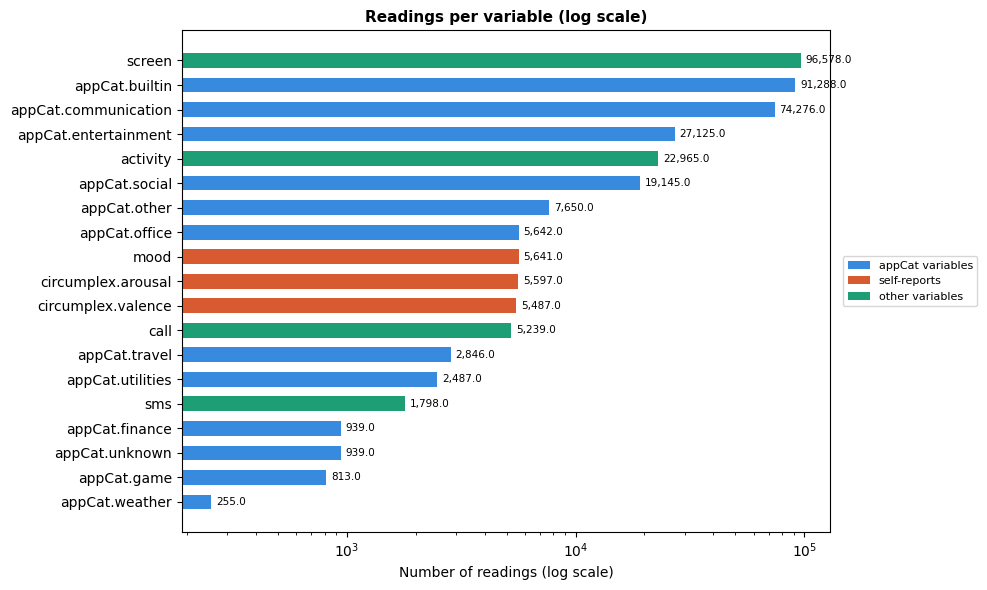

In [7]:
counts = stats["count"].sort_values(ascending=True)
colors_bar = [
    BLUE if "appCat" in v else
    CORAL if v in ("mood", "circumplex.arousal", "circumplex.valence") else
    TEAL
    for v in counts.index
]

plt.figure(figsize=(10, 6))
plt.barh(counts.index, counts.values, height=0.6, color=colors_bar)
plt.xscale("log")
plt.xlabel("Number of readings (log scale)")
plt.title("Readings per variable (log scale)")
plt.legend(
    handles=[
        mpatches.Patch(facecolor=BLUE, label="appCat variables"),
        mpatches.Patch(facecolor=CORAL, label="self-reports"),
        mpatches.Patch(facecolor=TEAL, label="other variables"),
    ],
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)
for value, variable in zip(counts.values, counts.index):
    plt.text(value * 1.05, variable, f"{value:,}", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

# Sensor data (screen, appCat) is sampled far more than self-reports (mood, arousal). Maybe table is enough to show this
# Need to understand how to handle this when we will pivot the data to wide format and have missing values for self-reports.

In [8]:
# Check and remove negative values for appCat.builtin (before aggregating to pivot)
is_builtin = df["variable"].eq("appCat.builtin")
is_negative_builtin = is_builtin & (df["value"] < 0)

print("Negative appCat.builtin rows:", int(is_negative_builtin.sum()))
df = df.loc[~is_negative_builtin].copy()
print("Remaining negative appCat.builtin rows:", int(((df["variable"] == "appCat.builtin") & (df["value"] < 0)).sum()))

Negative appCat.builtin rows: 3
Remaining negative appCat.builtin rows: 0


In [9]:
# Check and remove negative values for appCat.entertainment
is_entr = df["variable"].eq("appCat.entertainment")
is_negative_entr = is_entr & (df["value"] < 0)

print("Negative appCat.entertainment rows:", int(is_negative_entr.sum()))
df = df.loc[~is_negative_entr].copy()
print("Remaining negative appCat.entertainment rows:", int(((df["variable"] == "appCat.entertainment") & (df["value"] < 0)).sum()))

Negative appCat.entertainment rows: 1
Remaining negative appCat.entertainment rows: 0


In [10]:
# Creating wide format dataset
mood_data = (df[df["variable"].isin(["mood", "circumplex.arousal", "circumplex.valence", "activity"])]).sort_values(by=["id", "time"])
mood_pivot = mood_data.pivot_table(
    index=["id", "date"], 
    columns="variable", 
    values="value", 
    aggfunc=["mean", "max", "min", "std", "first", "last", "count"]
)
mood_pivot.columns = [f"{var}_{stat}" for stat, var in mood_pivot.columns]
mood_pivot = mood_pivot.reset_index()

mood_pivot.head()

,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,circumplex.valence_first,mood_first,activity_last,circumplex.arousal_last,circumplex.valence_last,mood_last,activity_count,circumplex.arousal_count,circumplex.valence_count,mood_count
0,AS14.01,2014-02-26,NaN,-0.25,0.750000,6.250000,NaN,1.0,1.0,7.0,...,0.0,6.0,NaN,1.0,1.0,7.0,NaN,4.0,4.0,4.0
1,AS14.01,2014-02-27,NaN,0.00,0.333333,6.333333,NaN,1.0,1.0,7.0,...,0.0,6.0,NaN,1.0,1.0,7.0,NaN,3.0,3.0,3.0
2,AS14.01,2014-03-20,0.081548,NaN,NaN,NaN,0.091667,NaN,NaN,NaN,...,NaN,NaN,0.091667,NaN,NaN,NaN,2.0,NaN,NaN,NaN
3,AS14.01,2014-03-21,0.134050,0.20,0.200000,6.200000,0.798387,1.0,1.0,7.0,...,0.0,6.0,0.000000,1.0,0.0,6.0,23.0,5.0,5.0,5.0
4,AS14.01,2014-03-22,0.236880,0.60,0.500000,6.400000,0.508475,1.0,1.0,7.0,...,1.0,7.0,0.000000,1.0,-1.0,5.0,16.0,5.0,4.0,5.0


In [11]:
## see that first user has first observation 26 Febr and third one 20 March

In [12]:
rec_vars = ['screen',
 'call',
 'sms',
 'appCat.builtin',
 'appCat.communication',
 'appCat.entertainment',
 'appCat.finance',
 'appCat.game',
 'appCat.office',
 'appCat.other',
 'appCat.social',
 'appCat.travel',
 'appCat.unknown',
 'appCat.utilities',
 'appCat.weather']

rec_data = (df[df["variable"].isin(rec_vars)]).sort_values(by=["id", "time"])
rec_pivot = rec_data.pivot_table(
    index=["id", "date"], 
    columns=["variable"], 
    values="value", 
    aggfunc=["sum"]
)
rec_pivot.columns = [f"{var}_{stat}" for stat, var in rec_pivot.columns]
rec_pivot = rec_pivot.reset_index()

rec_pivot.head()

,id,date,appCat.builtin_sum,appCat.communication_sum,appCat.entertainment_sum,appCat.finance_sum,appCat.game_sum,appCat.office_sum,appCat.other_sum,appCat.social_sum,appCat.travel_sum,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,2.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [13]:
df_wide = mood_pivot.merge(rec_pivot, on=["id", "date"], how="outer")
df_wide["day_of_week"] = df_wide["date"].dt.day_name()
df_wide["month"] = df_wide["date"].dt.month_name()
df_wide["weekend"] = df_wide["day_of_week"].isin(["Saturday", "Sunday"])
print("Wide shape:", df_wide.shape)
df_wide.head()

Wide shape: (1973, 48)


,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,appCat.travel_sum,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum,day_of_week,month,weekend
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Monday,February,False
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,Tuesday,February,False
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,2.0,Wednesday,February,False
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,3.0,Thursday,February,False
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Friday,February,False


In [14]:
gap_threshold = 3 # check gaps longer than 3 days
results = []
for part_id, group in df_wide.groupby('id'):
    valid = group[group["mood_mean"].notna()].sort_values('date')
        
    valid['gap_days'] = valid['date'].diff().dt.days
    big_gaps = valid[valid['gap_days'] > gap_threshold][['date', 'gap_days']]
    if not big_gaps.empty:
        big_gaps['id_num'] = part_id
        results.append(big_gaps)
    
pd.concat(results).sort_values(['id_num', 'date'])

,date,gap_days,id_num
26,2014-03-21,22.0,AS14.01
576,2014-03-27,12.0,AS14.12
942,2014-03-21,7.0,AS14.17


In [15]:
 # remove gaps longer than 3 days
result = []
for part_id, group in df_wide.groupby('id'):
    group = group.sort_values('date')
    valid_dates = group[group['mood_mean'].notna()]['date']
    gaps = valid_dates.diff()
    
    big_gap_dates = valid_dates[gaps.dt.days > 3]
    
    if not big_gap_dates.empty:
        cutoff = big_gap_dates.iloc[-1]
        n_before = (group['date'] < cutoff).sum()
        group = group[group['date'] >= cutoff]
        print(f"User {part_id}: remove {n_before} days before {cutoff.date()}")
    
    result.append(group)

df_consec = pd.concat(result, ignore_index=True)
print("Shape after removing gaps:", df_consec.shape)

User AS14.01: remove 26 days before 2014-03-21
User AS14.12: remove 27 days before 2014-03-27
User AS14.17: remove 29 days before 2014-03-21
Shape after removing gaps: (1891, 48)


In [16]:
# Start imputation
# create a row per each day 
df_daily = (df_consec.set_index('date')
           .groupby('id')
           .resample('D').asfreq()
           .drop(columns=['id'])
           .reset_index()).copy()

/var/folders/z3/h9qtkxfd38q8llwvssylbv8h0000gn/T/ipykernel_52445/803115517.py:5: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .resample('D').asfreq()


In [17]:
df_daily.isna().sum()

id                             0
date                           0
activity_mean                868
circumplex.arousal_mean      800
circumplex.valence_mean      802
mood_mean                    800
activity_max                 868
circumplex.arousal_max       800
circumplex.valence_max       802
mood_max                     800
activity_min                 868
circumplex.arousal_min       800
circumplex.valence_min       802
mood_min                     800
activity_std                 878
circumplex.arousal_std       825
circumplex.valence_std       829
mood_std                     825
activity_first               868
circumplex.arousal_first     800
circumplex.valence_first     802
mood_first                   800
activity_last                868
circumplex.arousal_last      800
circumplex.valence_last      802
mood_last                    800
activity_count               868
circumplex.arousal_count     800
circumplex.valence_count     800
mood_count                   800
appCat.bui

In [18]:
# fill zero for appCat vars
zero_vars = ['appCat.builtin_sum', 'appCat.communication_sum', 'appCat.entertainment_sum',
             'appCat.finance_sum', 'appCat.game_sum', 'appCat.office_sum',
             'appCat.other_sum', 'appCat.social_sum', 'appCat.travel_sum',
             'appCat.unknown_sum', 'appCat.utilities_sum', 'appCat.weather_sum',
             'call_sum', 'screen_sum', 'sms_sum']

for col in zero_vars:
    if col in df_daily.columns:
        df_daily[col] = df_daily[col].fillna(0) 

In [19]:
# check that we filled zeros for appCat variables
df_daily[zero_vars].isna().sum()

appCat.builtin_sum          0
appCat.communication_sum    0
appCat.entertainment_sum    0
appCat.finance_sum          0
appCat.game_sum             0
appCat.office_sum           0
appCat.other_sum            0
appCat.social_sum           0
appCat.travel_sum           0
appCat.unknown_sum          0
appCat.utilities_sum        0
appCat.weather_sum          0
call_sum                    0
screen_sum                  0
sms_sum                     0
dtype: int64

In [20]:
# fill for mood and circumplex vars using different methods (LOCF, interpolation)
target_vars = ["mood_mean", "circumplex.arousal_mean", "circumplex.valence_mean"] # could be done also for the other vars
# method 1: forward fill
df_LOCF = df_daily.copy()
df_LOCF = df_LOCF.sort_values(['id', 'date'])
for var in target_vars:
   # limit: 2 days
   df_LOCF[var] = df_LOCF.groupby("id")[var].ffill(limit=2)

In [21]:
# method 2:interpolation
df_interpolation = df_daily.copy()
df_interpolation = df_interpolation.sort_values(['id', 'date'])
for var in target_vars:
    # two known neighbors
    df_interpolation[var] = df_interpolation.groupby("id")[var].transform(
        lambda x: x.interpolate(method='linear', limit=2, limit_direction='forward'))   

In [22]:
df_LOCF[target_vars].isna().sum()

mood_mean                  766
circumplex.arousal_mean    766
circumplex.valence_mean    766
dtype: int64

In [23]:
df_interpolation[target_vars].isna().sum()

mood_mean                  766
circumplex.arousal_mean    766
circumplex.valence_mean    766
dtype: int64

In [24]:
# Clean NAs in mood_mean (self-reports), if gap is larger than 2 days
print("Number of NAs in mood_mean before dropping:", df_LOCF["mood_mean"].isnull().sum())
df_LOCF.dropna(subset=["mood_mean"], inplace=True)
print("Number of NAs in mood_mean after dropping:", df_LOCF["mood_mean"].isnull().sum())

Number of NAs in mood_mean before dropping: 766
Number of NAs in mood_mean after dropping: 0


In [25]:
# Clean NAs in mood_mean (self-reports), if gap is larger than 2 days
print("Number of NAs in mood_mean before dropping:", df_interpolation["mood_mean"].isnull().sum())
df_interpolation.dropna(subset=["mood_mean"], inplace=True)
print("Number of NAs in mood_mean after dropping:", df_interpolation["mood_mean"].isnull().sum())

Number of NAs in mood_mean before dropping: 766
Number of NAs in mood_mean after dropping: 0


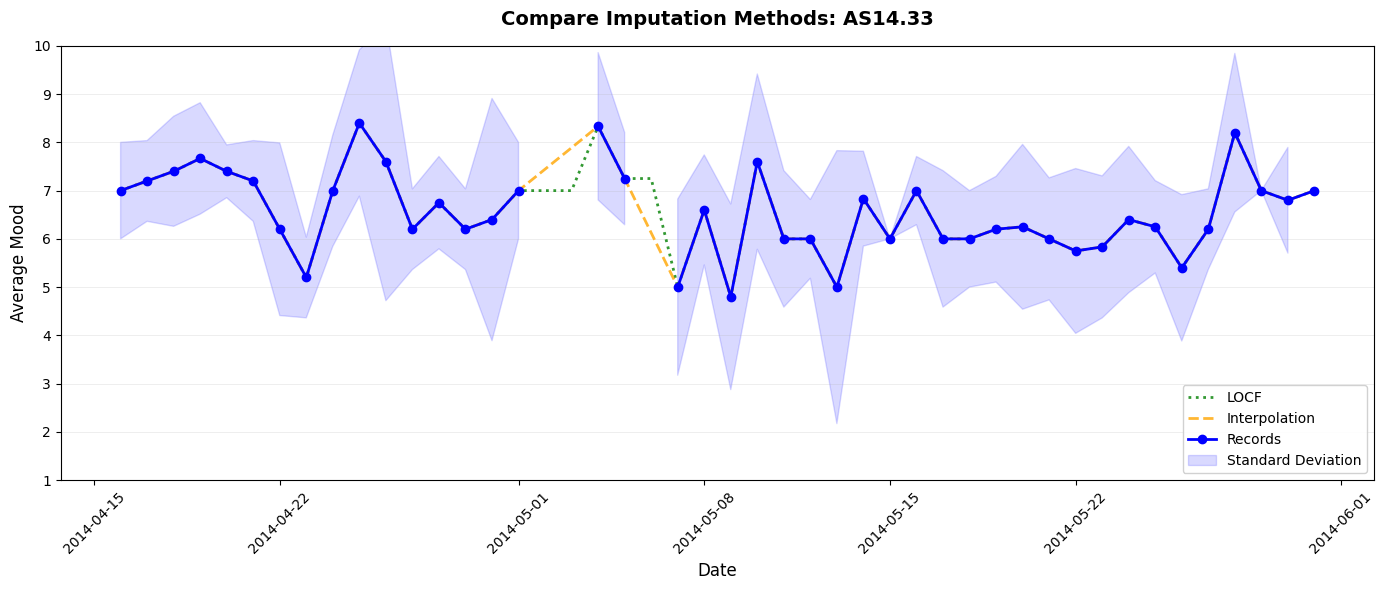

In [26]:
# Plots
# Plot 1: Time series of mood_mean + std users (before and after imputation)
user_sel = "AS14.33" # select users: see the difference btw "AS14.01" and "AS14.33"

df_orig = df_wide[df_wide["id"] == user_sel]
df_locf = df_LOCF[df_LOCF["id"] == user_sel]
df_roll = df_interpolation[df_interpolation["id"] == user_sel]


plt.figure(figsize=(14, 6))
plt.plot(df_locf["date"], df_locf["mood_mean"], 
         label="LOCF", color="green", linestyle=":", linewidth=2, alpha=0.8)

plt.plot(df_roll["date"], df_roll["mood_mean"], 
         label="Interpolation", color="orange", linestyle="--", linewidth=2, alpha=0.8)

plt.plot(df_orig["date"], df_orig["mood_mean"], 
         label="Records", color="blue", marker="o", markersize=6, linewidth=2)

plt.fill_between(df_orig["date"], 
                 df_orig["mood_mean"] - df_orig["mood_std"], 
                 df_orig["mood_mean"] + df_orig["mood_std"], 
                 color="blue", alpha=0.15, label="Standard Deviation")

plt.title(f"Compare Imputation Methods: {user_sel}", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Mood", fontsize=12)
plt.ylim(1, 10) 
plt.legend(loc="lower right", framealpha=0.9)
plt.grid(True, axis='y', alpha=0.3) 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

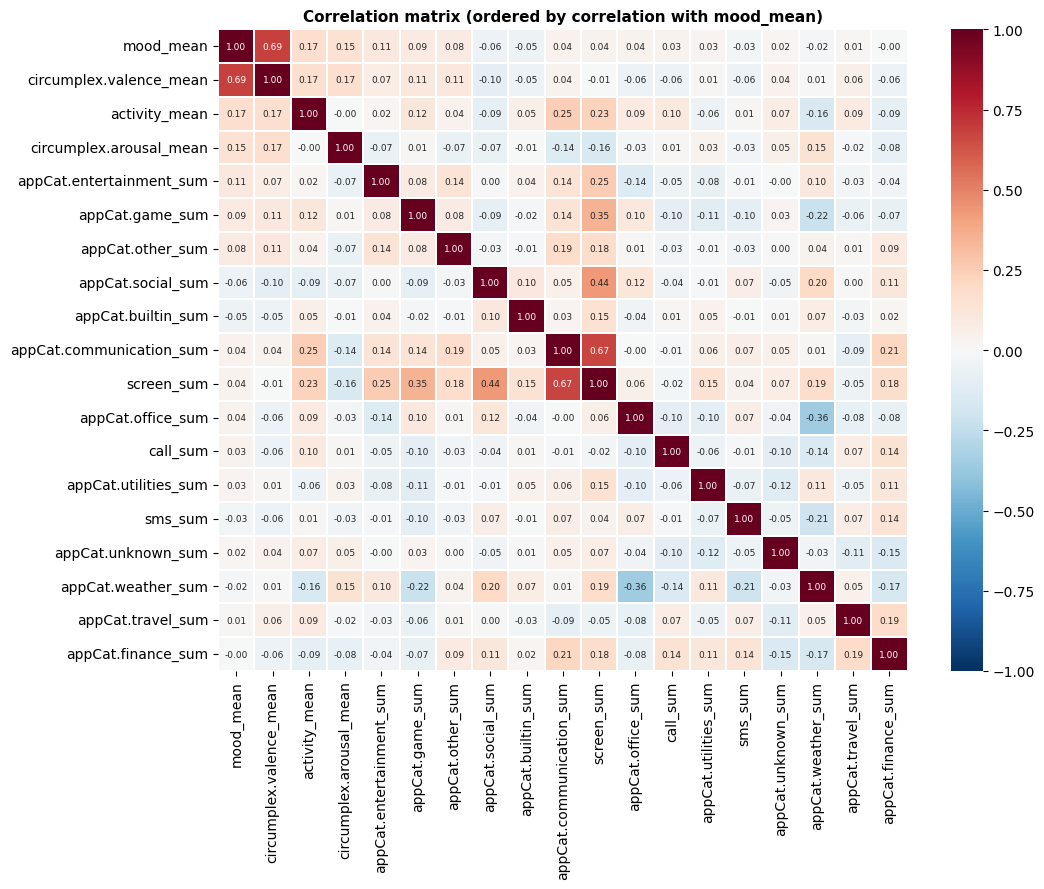

In [27]:
cols_to_correlate = ["mood_mean", "circumplex.arousal_mean", "circumplex.valence_mean", 'appCat.builtin_sum',
       'appCat.communication_sum', 'appCat.entertainment_sum',
       'appCat.finance_sum', 'appCat.game_sum', 'appCat.office_sum',
       'appCat.other_sum', 'appCat.social_sum', 'appCat.travel_sum',
       'appCat.unknown_sum', 'appCat.utilities_sum', 'appCat.weather_sum',
       'call_sum', 'screen_sum', 'sms_sum', "activity_mean"]
corr_matrix = df_wide[cols_to_correlate].corr()
# order all variables by their correlation with mood_mean
order = corr_matrix["mood_mean"].abs().sort_values(ascending=False).index
corr_matrix = corr_matrix.loc[order, order]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": 6.5},
    ax=ax,
)
ax.set_title("Correlation matrix (ordered by correlation with mood_mean)", fontweight="bold")
plt.tight_layout()
plt.show()

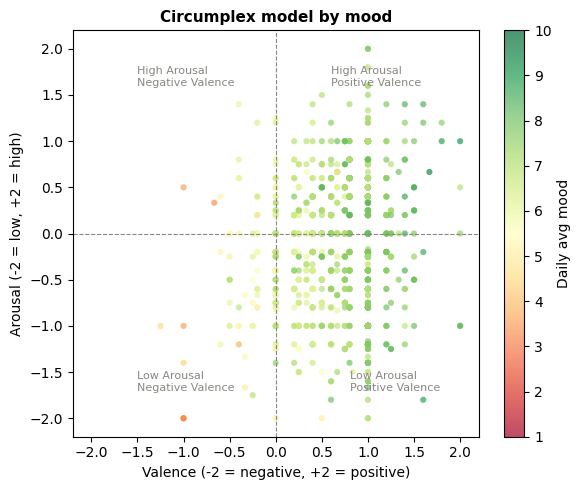

In [28]:
circ = df_wide[["circumplex.valence_mean", "circumplex.arousal_mean", "mood_mean"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(circ["circumplex.valence_mean"], circ["circumplex.arousal_mean"],
                c=circ["mood_mean"], cmap="RdYlGn", vmin=1, vmax=10,
                alpha=0.7, linewidths=0, s=20)
plt.colorbar(sc, ax=ax, label="Daily avg mood")
plt.axhline(0, color=GRAY, lw=0.8, ls="--")
plt.axvline(0, color=GRAY, lw=0.8, ls="--")
plt.ylim(-2.2, 2.2)
plt.xlim(-2.2, 2.2)
plt.xlabel("Valence (-2 = negative, +2 = positive)")
plt.ylabel("Arousal (-2 = low, +2 = high)")
plt.title("Circumplex model by mood")
for x, y, lbl in [(.6, 1.6, "High Arousal\nPositive Valence"), (.8, -1.7, "Low Arousal\nPositive Valence"),
                   (-1.5, 1.6, "High Arousal\nNegative Valence"), (-1.5, -1.7, "Low Arousal\nNegative Valence")]:
    plt.text(x, y, lbl, fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()

## Notes

### 1.A
- data is between 02/2014 until 06/2014, but only for 2 people feb and june are included
- appCat.builtin and entertainment have min negative values: remove or clip?
- usage times have extreme outliers (e.g. screen max is approx 2.7 hours, social is 8h and office is 9h)
- call and sms mark events
- mood mean = 7.0, std = 1.0
- circumplex.valence mean = 0.69 (positive), arousal mean = -0.10 (calm)


### 1.B Data Cleaning

- Imputation
(i) There are a lot of not available data points. In areas like valence, mood and arousal I will assume that these are genuinely missed days and that these points will have to be imputed. On the other hand, there are multiple NaNs in columns such as finance or weather apps. For now I will replace these NaNs with 0s, as my assumption is that people did not use these apps on certain days, and that their use would've been tracked automatically.

(ii) LOCF is a common method we used in our bachelor when dealing with clinical data, so I kind of chose it because I am a familiar with it (and it's super easy to implement). I think it also makes sense here, if a participant forgot to self report, then taking the value from their last known report would be fair, albeit a generalizaition of their mood.

Sources:

https://medium.com/@aaabulkhair/data-imputation-demystified-time-series-data-69bc9c798cb7 (not clear scientific journal)

https://www.lexjansen.com/nesug/nesug09/po/PO12.pdf

Preliminary Discussion:

A possible problem that comes with LOCF is that it may be introducing bias in cases where data is not stationary. Here I am assuming that yesterdays mood value can be assumed for today, and although I don't think it's an invalid assumption, I would say it introduces bias. Seems like not that many NaNs were imputed, but that's largely due to the first rows of the dataset being empty. The method cannot impute retroactivcely. And if we did decide to backfill those, that would be a lot of made up datapoints.

(iii) Mean imputation: Clearly this method did not impute as many data points as the previously used LOCF method. If I enlarge the time window, then more data points are imputed but I thought that 3 days was a reasonable amount (although I am struggling to find a source to support mt decision making here). From these results, I think the LOCF method makes more sense to me and is more effective here. It manages to impute more data points, and is based only off the emotion of the previous day not off of three days prior. Logically I think the argument for using it in this context is more sound than then rolling mean.**INTERPOLATION??**
 
- currently most cleaned version of data: df_wide_LOCF_cleaned **Based on imputation method we use...**

- could still remove extremities, I just focused on removing values that were actually impossible. But I wasn't sure how skeptical I could be with the values for certain app usages. **WINSORIZATION? Check also after modelling**

    - for example: the maximum time for using built in apps is almost 11 hours in a day. Logically I don't think someone is spending 11 hours in the calendar app. So I theorized doing a percentile cutoff of maybe the top 1% and bottom 1%. But he hasn't mentioned this in the lectures, and I feel I can't really justify it right now.

- data should be in correct format and ready for part 1C

- the assignment asks: "also consider what to do with prolonged periodsof missing data in a time series."
    - I just removed those initial 22 days of rows of NaNs, instead of imputing it. In my eyes, filling in that much data would be wrong. But that's more coming from my psychology background and I wonder whether he is expecting us to impute that data somehow, perhaps with a more advanced method? I'm not sure. Many decisions in this cleaning part that I think we can discuss together. **YES and done!**
 

## 1C - FEATURE ENGINEERING
#### Adding the target value - next day mood

In [29]:
# use either df_LOCF or df_interpolation for the rest of the analyses

In [30]:
df_interpolation['mood_next'] = (df_interpolation.groupby('id')['mood_mean'].shift(-1))
df_interpolation.head() 


,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum,day_of_week,month,weekend,mood_next
0,AS14.01,2014-03-21,0.134050,0.2,0.2,6.20,0.798387,1.0,1.0,7.0,...,0.000,598.754,0.000,6.0,17978.907000,0.0,Friday,March,False,6.40
1,AS14.01,2014-03-22,0.236880,0.6,0.5,6.40,0.508475,1.0,1.0,7.0,...,0.000,117.621,0.000,3.0,6142.161000,1.0,Saturday,March,True,6.80
2,AS14.01,2014-03-23,0.142741,0.2,0.8,6.80,0.313559,1.0,1.0,8.0,...,0.000,30.086,30.386,0.0,6773.832001,0.0,Sunday,March,True,6.00
3,AS14.01,2014-03-24,0.078961,0.8,0.0,6.00,0.361345,2.0,1.0,7.0,...,0.000,178.732,0.000,10.0,15047.351001,0.0,Monday,March,False,6.75
4,AS14.01,2014-03-25,0.098374,0.5,0.5,6.75,0.594828,1.0,1.0,8.0,...,235.223,222.893,0.000,0.0,21475.354999,1.0,Tuesday,March,False,6.60


In [31]:
#now the last day for each subject has a nan target - should we drop it?  ## YES
print("Number of missing values in mood_next:", df_interpolation["mood_next"].isna().sum())
# drop:
df_interpolation = df_interpolation.dropna(subset=['mood_next'])

Number of missing values in mood_next: 27


In [32]:
for lag in [1, 2, 3]: 
    df_interpolation[f'mood_lag{lag}'] = df_interpolation.groupby('id')['mood_mean'].shift(lag)
    df_interpolation[f'activity_lag{lag}'] = df_interpolation.groupby('id')['activity_mean'].shift(lag)
    df_interpolation[f"arousal_lag{lag}"] = df_interpolation.groupby('id')['circumplex.arousal_mean'].shift(lag)
    df_interpolation[f"valence_lag{lag}"] = df_interpolation.groupby('id')['circumplex.valence_mean'].shift(lag)

df_interpolation.head()

,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,arousal_lag1,valence_lag1,mood_lag2,activity_lag2,arousal_lag2,valence_lag2,mood_lag3,activity_lag3,arousal_lag3,valence_lag3
0,AS14.01,2014-03-21,0.134050,0.2,0.2,6.20,0.798387,1.0,1.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AS14.01,2014-03-22,0.236880,0.6,0.5,6.40,0.508475,1.0,1.0,7.0,...,0.2,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AS14.01,2014-03-23,0.142741,0.2,0.8,6.80,0.313559,1.0,1.0,8.0,...,0.6,0.5,6.2,0.134050,0.2,0.2,NaN,NaN,NaN,NaN
3,AS14.01,2014-03-24,0.078961,0.8,0.0,6.00,0.361345,2.0,1.0,7.0,...,0.2,0.8,6.4,0.236880,0.6,0.5,6.2,0.13405,0.2,0.2
4,AS14.01,2014-03-25,0.098374,0.5,0.5,6.75,0.594828,1.0,1.0,8.0,...,0.8,0.0,6.8,0.142741,0.2,0.8,6.4,0.23688,0.6,0.5


In [33]:
#adding a weekday
df_interpolation["day_of_week"] = df_interpolation["date"].dt.day_name()
df_interpolation["month"] = df_interpolation["date"].dt.month_name()
df_interpolation["weekend"] = df_interpolation["day_of_week"].isin(["Saturday", "Sunday"])
df_interpolation.columns

Index(['id', 'date', 'activity_mean', 'circumplex.arousal_mean',
       'circumplex.valence_mean', 'mood_mean', 'activity_max',
       'circumplex.arousal_max', 'circumplex.valence_max', 'mood_max',
       'activity_min', 'circumplex.arousal_min', 'circumplex.valence_min',
       'mood_min', 'activity_std', 'circumplex.arousal_std',
       'circumplex.valence_std', 'mood_std', 'activity_first',
       'circumplex.arousal_first', 'circumplex.valence_first', 'mood_first',
       'activity_last', 'circumplex.arousal_last', 'circumplex.valence_last',
       'mood_last', 'activity_count', 'circumplex.arousal_count',
       'circumplex.valence_count', 'mood_count', 'appCat.builtin_sum',
       'appCat.communication_sum', 'appCat.entertainment_sum',
       'appCat.finance_sum', 'appCat.game_sum', 'appCat.office_sum',
       'appCat.other_sum', 'appCat.social_sum', 'appCat.travel_sum',
       'appCat.unknown_sum', 'appCat.utilities_sum', 'appCat.weather_sum',
       'call_sum', 'screen_sum', '

We should decide if we want to do a neural network or aggregate to create attributes. 

"Because regression
models are sensitive to large differences in the scales of
independent variables, we transformed the scales of the variables
to the standard normal distribution (ie, 99.7% of values ranging
between –3 and 3). Interrelated variables (eg, top 5 call and top
5 app use) were normalized to the 0-1 range,"" - i have to see if we maybe want to scale it differently then standard scaler later

In [40]:
df_feature = df_interpolation.copy # copy of df that will be

df_feature = df_feature.rename(columns={'circumplex.arousal_mean': 'arousal_mean','circumplex.valence_mean': 'valence_mean'})
df_feature = df_feature.sort_values(['id', 'date']) #sorting df by id and date - will be used to make aggregartes of the rolling window

predictor_cols = ['mood_mean', 'circumplex.arousal_mean', 'circumplex.valence_mean'] # for now we only keep those columns - I have to think about how we can average the other predictors like num calls etc. 
window = 4 #the prediciton is based on past 4 days - in the example they used past 5 days (we can change it)
instances = []

for patient_id, group in df_feature.groupby('id'): #separate df for each patient to prevent data leak - this also handles patients having different starting dates
    group = group.reset_index(drop=True) #reset index 
    for t in range(window, len(group)): #starting at day 4
        window_days = group.iloc[t - window:t] #4 days befor day t
        t_day = group.iloc[t] #prediction day
        
        row = {'id': patient_id, 'date': t_day['date']}
        
        for col in predictor_cols: #summary stats over the 4 days - autmatically calucaltes the stats for all predictor columns
            name = col.replace('_mean', '') 
            row[f'{name}_mean_{window}d'] = window_days[col].mean()   # average mood/arousal/valence over window
            row[f'{name}_std_{window}d']  = window_days[col].std()    # standard deviation
            row[f'{name}_min_{window}d']  = window_days[col].min()    # lowest value in the window
            row[f'{name}_max_{window}d']  = window_days[col].max()    # max value in the window
            row[f'{name}_last_{window}d'] = window_days[col].iloc[-1] # most recent value (yesterday)
        
        row['target_mood'] = t_day['mood_mean'] #target mood value
        instances.append(row) # add the prediction row to list

df_ml = pd.DataFrame(instances) #new df for ML prediction
display(df_ml.shape)
display(df_ml.head())

(1153, 18)

,id,date,mood_mean_4d,mood_std_4d,mood_min_4d,mood_max_4d,mood_last_4d,arousal_mean_4d,arousal_std_4d,arousal_min_4d,arousal_max_4d,arousal_last_4d,valence_mean_4d,valence_std_4d,valence_min_4d,valence_max_4d,valence_last_4d,target_mood
0,AS14.01,2014-03-25,6.3500,0.341565,6.0,6.8,6.00,0.450,0.300000,0.2,0.8,0.8,0.375,0.350000,0.0,0.8,0.0,6.75
1,AS14.01,2014-03-26,6.4875,0.370529,6.0,6.8,6.75,0.525,0.250000,0.2,0.8,0.5,0.450,0.331662,0.0,0.8,0.5,6.60
2,AS14.01,2014-03-27,6.5375,0.368273,6.0,6.8,6.60,0.325,0.427200,-0.2,0.8,-0.2,0.475,0.340343,0.0,0.8,0.6,7.00
3,AS14.01,2014-03-28,6.5875,0.425000,6.0,7.0,7.00,0.325,0.427200,-0.2,0.8,0.2,0.475,0.340343,0.0,0.8,0.8,6.40
4,AS14.01,2014-03-29,6.6875,0.252900,6.4,7.0,6.40,-0.025,0.478714,-0.6,0.5,-0.6,0.625,0.125831,0.5,0.8,0.6,8.00


09.04 review 

I merged 1A and 1B: 
- we remove only negative values (4 in total) for a couple of variables because we consider them as invalid since they would imply a negative screen time
- we remove pivot the dataset by performing aggregations using more stats than only the mean since it might be interesting (however these are not yet imputed). We need to check what types of variable "activity", "calls" and "sms" are and how to interpret them. Compared to Davids original code, I summed calls and sms since i think they can be interpreted as number of calls/sms throughout the day. 
- we see that some users have larger (>3? what do you think is large?) gaps in mood recordings, so we remove data before larger gaps 
- we perform imputation: 0 for recorded variables since it means user did not use the app. For mood related variables we use either forward fill or interpolation (if David agrees, it might be better than the mean. Even though we should discuss it more)
- for plots, i kept only three but feel free to suggest more interesting/relevant visualizations

- for feature engineering, basic aggregation is already done, maybe we can do some more rolling mean/standard dev,
 and check whether there are any interesting relationships between max, min, etc, ... (already in the dataset)
- maybe we could try to recode a combination of valence + arousal, e.g. one category if they are both positive, one if they are both negative, etc

- for modelling, would be nice to explore 2/3 models from the easiest to a neural network

# 2A. - CLASSIFICATION
predicting a fixed number of classes with the mood of the next day

### determining classes

count    1153.000000
mean        6.992599
std         0.734966
min         3.000000
25%         6.600000
50%         7.000000
75%         7.500000
max         9.333333
Name: target_mood, dtype: float64


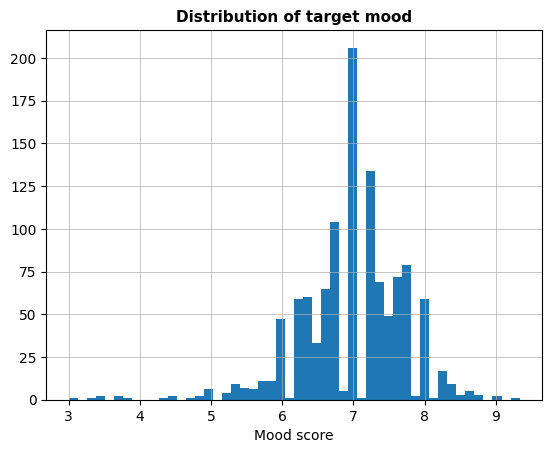

In [60]:
print(df_ml['target_mood'].describe())
df_ml['target_mood'].hist(bins=50)
plt.xlabel('Mood score')
plt.title('Distribution of target mood')
plt.show()

### a) Random forest
use the data from task 1C

### b) Recurrent neural network
(inherently temporal)
* good evaluation set up

# 4 - numerical prediction

### a) Mulitple linear regression - non temporal 


In [ ]:
# features and target for the regression
X = df_ml.drop(columns=['id', 'date', 'target_mood'])
y = df_ml['target_mood']
groups = df_ml['id']

# split into train and test by keeping patients in either set
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# fitting the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# evaluation
y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
acc   = accuracy_score(y_val, preds)
auc   = roc_auc_score(y_val, probs)

print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


# extracting coefficients
coef_df = pd.DataFrame({
    'feature':     X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

display(coef_df)

RMSE: 0.593
R²:   0.225


,feature,coefficient
7,arousal_min_4d,-0.376688
6,arousal_std_4d,-0.338931
0,mood_mean_4d,0.321527
2,mood_min_4d,0.291964
8,arousal_max_4d,0.255917
3,mood_max_4d,-0.229014
12,valence_min_4d,-0.223898
11,valence_std_4d,-0.153330
1,mood_std_4d,0.146546
4,mood_last_4d,0.129590


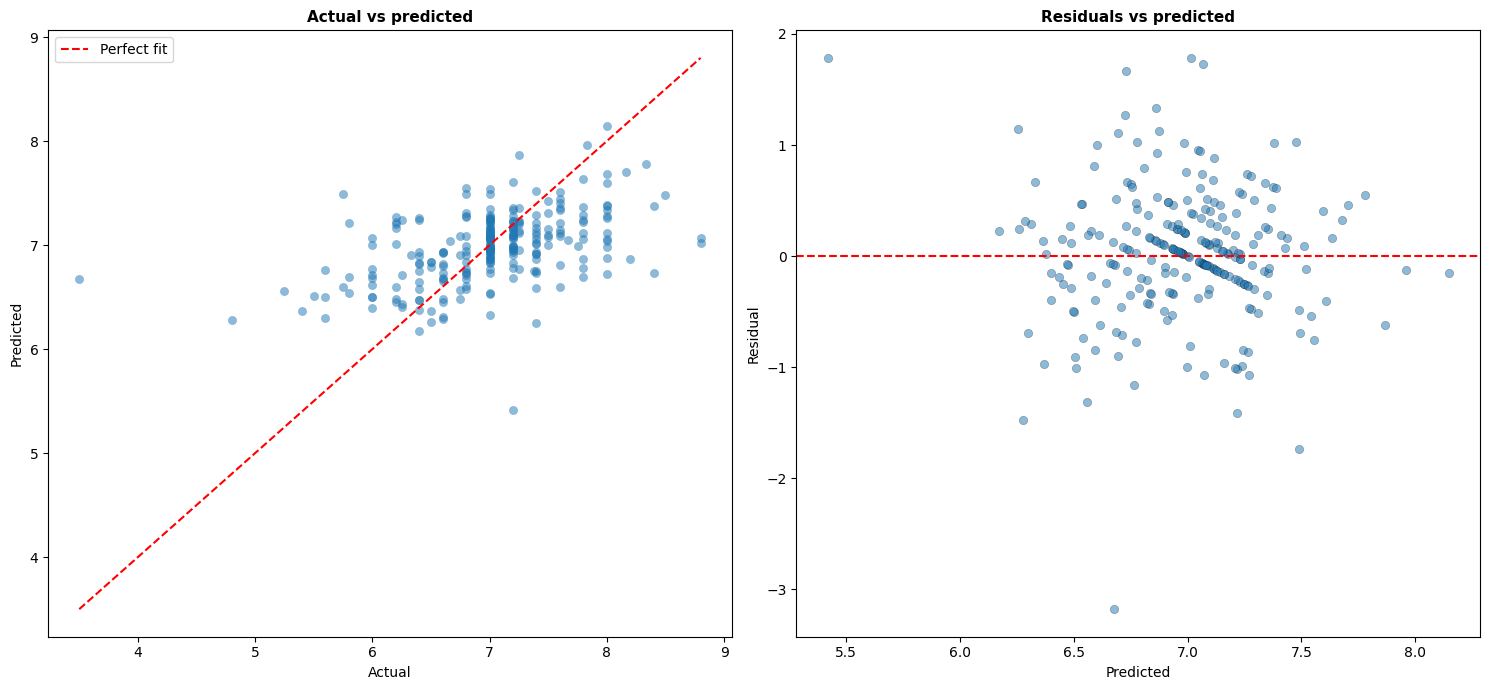

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# 1. actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,  linewidths=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs predicted')
axes[0].legend()

# 2. Residuals vs Predicted
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs predicted')

plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'Feature coefficients')

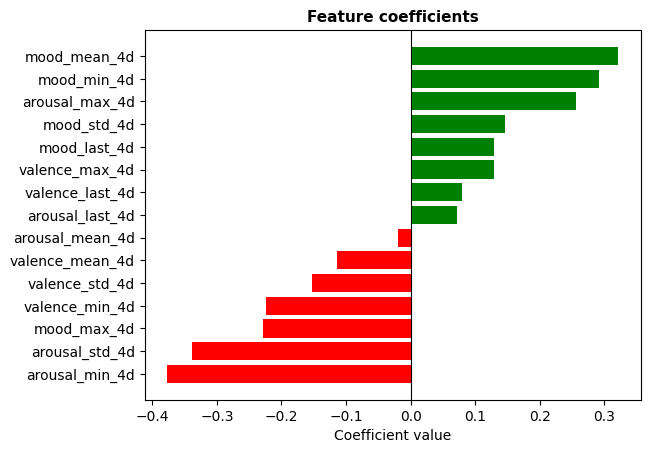

In [53]:
# Feature coefficients
coef_sorted = coef_df.sort_values('coefficient')
colors = ['red' if c < 0 else 'green' for c in coef_sorted['coefficient']]
plt.barh(coef_sorted['feature'], coef_sorted['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient value')
plt.title('Feature coefficients')

### b) RNN - temporal